# rs-embed Demo: Simple Crop Yield Example

This notebook keeps only the core steps:

1. Load Illinois maize points from SPAM.
2. Export embeddings for a small model list.
3. Train a simple random forest regressor.
4. Check which model works best.



## Before You Run

You need:

- `rs-embed` installed
- GEE authenticated if you want to export on the fly
- SPAM files under `spam2020V2r0_global_yield/`
  - `spam2020V2r0_global_H_TA.csv`
  - `spam2020V2r0_global_Y_TA.csv`

If GEE is not ready yet, run `earthengine authenticate` first.

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from rs_embed import PointBuffer, TemporalSpec, OutputSpec, export_batch
from examples.utils_demo import *


# Replace your path here
H_CSV = "./spam2020V2r0_global_H_TA.csv"
Y_CSV = "./spam2020V2r0_global_Y_TA.csv"
EXPORT_ROOT = Path(os.getenv("DEMO_EXPORT_DIR", "/demo_simple")).expanduser()

SPAM_CROP_COL = os.getenv("SPAM_CROP_COL", "MAIZ_A").upper()
COUNTRY_CODE = os.getenv("SPAM_COUNTRY_CODE", "US").upper()
STATE_NAME = os.getenv("SPAM_STATE", "Illinois")
# LABEL_YEAR = int(os.getenv("SPAM_LABEL_YEAR", "2020"))
MIN_AREA_HA = float(os.getenv("MAIZ_AREA_MIN_HA", "2500"))
BUFFER_M = int(os.getenv("BUFFER_M", "2000"))

# Select model as needed here
MODEL_LIST = [
    "satmae",
    "remoteclip",
    "satmaepp",
    "wildsat",
    "terrafm",
    "dofa",
    "thor",
    "satvision",
    "agrifm",
]


EMBED_START = os.getenv("EMBED_START", "2019-06-01")
EMBED_END = os.getenv("EMBED_END", "2019-08-31")
TEMPORAL = TemporalSpec.range(EMBED_START, EMBED_END)

TEST_SIZE = float(os.getenv("REG_TEST_SIZE", "0.25"))
MIN_SAMPLES = int(os.getenv("MIN_MODEL_SAMPLES", "30"))

EE_PROJECT = os.getenv("EE_PROJECT")
print(
    {
        "EXPORT_ROOT": str(EXPORT_ROOT),
        "MODEL_LIST": MODEL_LIST,
        # "LABEL_YEAR": LABEL_YEAR,
        "BUFFER_M": BUFFER_M,
        "TEMPORAL": [EMBED_START, EMBED_END],
    }
)


SAVE_INPUTS = bool(int(os.getenv("SAVE_INPUTS", "1")))

{'EXPORT_ROOT': 'examples/exports/demo_simple', 'MODEL_LIST': ['satmae', 'remoteclip', 'satmaepp', 'wildsat', 'terrafm', 'dofa', 'thor', 'satvision', 'agrifm'], 'BUFFER_M': 2000, 'TEMPORAL': ['2019-06-01', '2019-08-31']}


## 0. Illinois Boundary

In [2]:
roi_geom = None
illinois_rings = []
center_lon, center_lat = np.nan, np.nan

try:
    import ee

    ee_initialize(ee, EE_PROJECT)
    states_fc = ee.FeatureCollection("TIGER/2018/States")
    roi_feat = states_fc.filter(ee.Filter.eq("NAME", "Illinois")).first()
    roi_geom = roi_feat.geometry()
    center_lon, center_lat = roi_geom.centroid(maxError=100).coordinates().getInfo()
    illinois_rings = rings_from_geom_info(roi_geom.getInfo())
    print(f"ROI center: lon={center_lon:.4f}, lat={center_lat:.4f}")
except Exception as e:
    print("Boundary plot fallback:", e)


def draw_illinois_boundary(ax, color="#222222", linewidth=1.1):
    for ring in illinois_rings:
        if ring.ndim == 2 and ring.shape[1] >= 2:
            ax.plot(ring[:, 0], ring[:, 1], color=color, linewidth=linewidth)

ROI center: lon=-89.1500, lat=40.1003


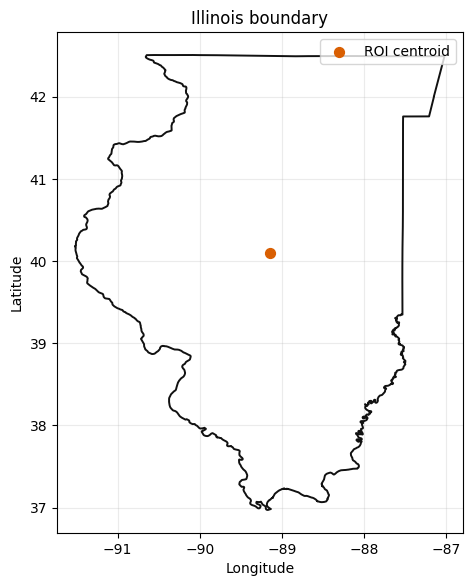

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
draw_illinois_boundary(ax, color="#111111", linewidth=1.4)
if np.isfinite(center_lon) and np.isfinite(center_lat):
    ax.scatter([center_lon], [center_lat], s=50, color="#d95f02", label="ROI centroid")
ax.set_title("Illinois boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
if np.isfinite(center_lon) and np.isfinite(center_lat):
    ax.legend(loc="upper right")
ax.grid(alpha=0.25)
plt.show()

## 1. Load SPAM Points and Labels

We keep only Illinois maize grids with enough planted area, then join the yield label.

In [4]:
def load_spam_value(csv_path: Path, value_name: str) -> pd.DataFrame:
    usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
    table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
    table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

    table["grid_code"] = table["grid_code"].astype(str)
    table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
    table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
    table["year_data"] = table["year_data"].astype(str)
    table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

    table = table[
        table["FIPS0"].eq(COUNTRY_CODE)
        & table["ADM1_NAME"].str.contains(STATE_NAME, case=False, na=False)
        # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
    ]

    return table[["grid_code", "lon", "lat", value_name]].dropna()


area_df = load_spam_value(H_CSV, "maize_area_ha")
area_df = area_df[area_df["maize_area_ha"] >= MIN_AREA_HA].drop_duplicates("grid_code")

yield_df = load_spam_value(Y_CSV, "label")
yield_df = yield_df[yield_df["label"] > 0].drop_duplicates("grid_code")

df = (
    area_df.merge(yield_df[["grid_code", "label"]], on="grid_code", how="inner")
    .sort_values(["lat", "lon"])
    .reset_index(drop=True)
)

if df.empty:
    raise RuntimeError("No Illinois points found after filtering.")

spatials = [
    PointBuffer(lon=float(row.lon), lat=float(row.lat), buffer_m=BUFFER_M)
    for row in df.itertuples(index=False)
]
point_names = [f"p{i:05d}" for i in range(len(spatials))]

print(f"points={len(df)}")
print(df[["maize_area_ha", "label"]].describe().T)
df.head()

points=991
               count         mean         std     min      25%     50%  \
maize_area_ha  991.0  3160.181837  420.232955  2502.0  2821.45  3145.4   
label          991.0     9.551261    0.559524     7.1     9.50     9.7   

                  75%     max  
maize_area_ha  3412.4  4593.0  
label             9.8    11.8  


,grid_code,lon,lat,maize_area_ha,label
0,2705420,-88.2917,37.7917,4089.1,11.8
1,2705421,-88.2083,37.7917,4351.8,11.8
2,2701101,-88.2083,37.8750,4248.7,11.8
3,2692460,-88.2917,38.0417,2502.7,9.9
4,2692462,-88.1250,38.0417,2661.5,9.8


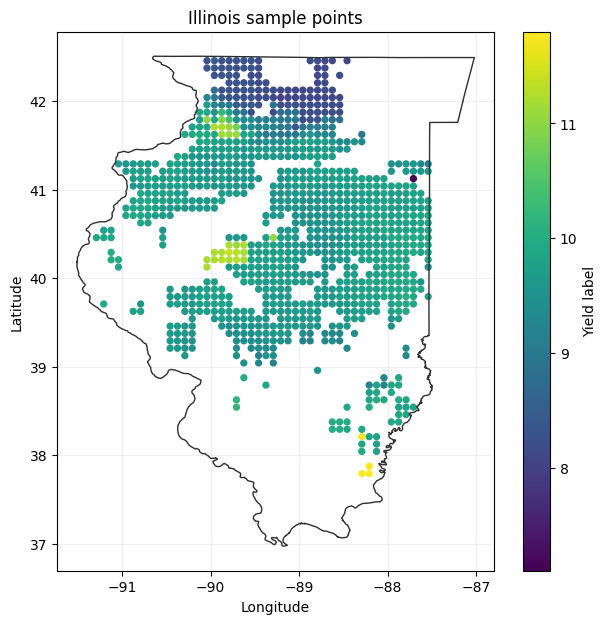

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 7.0))
draw_illinois_boundary(ax, color="#2f2f2f", linewidth=1.0)
sc = ax.scatter(df["lon"], df["lat"], c=df["label"], s=18, cmap="viridis")
plt.colorbar(sc, ax=ax, label="Yield label")
ax.set_title("Illinois sample points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
plt.show()

## 2. Export Embeddings

This notebook reuses old exports if `EXPORT_ROOT` already contains `p*.npz` files.
If you want a fresh run, point `DEMO_EXPORT_DIR` to a new folder or delete the old one.

In [6]:
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
has_export = any(EXPORT_ROOT.glob("p*.npz")) or (EXPORT_ROOT / "_all_points_manifest.json").exists()

if has_export:
    print(f"Reuse existing exports from: {EXPORT_ROOT}")
else:
    from rs_embed import ExportConfig, ExportTarget

    manifests = export_batch(
        spatials=spatials,
        temporal=TEMPORAL,
        models=MODEL_LIST,
        target=ExportTarget.per_item(str(EXPORT_ROOT), names=point_names),
        output=OutputSpec.grid(),
        backend="gee",
        device="auto",
        config=ExportConfig(
            save_inputs=SAVE_INPUTS,
            save_embeddings=True,
            save_manifest=True,
            chunk_size=8,
            num_workers=4,
            resume=True,
            continue_on_error=True,
            show_progress=True,
            input_prep="resize",  # you can chage it to 'tile' if you want to keep original resolution
        ),
    )
    print(f"exported_manifests={len(manifests)}")

Reuse existing exports from: examples/exports/demo_simple


## 2.1 Preview One Exported Patch

This works when the export saved inputs (`SAVE_INPUTS=1`).

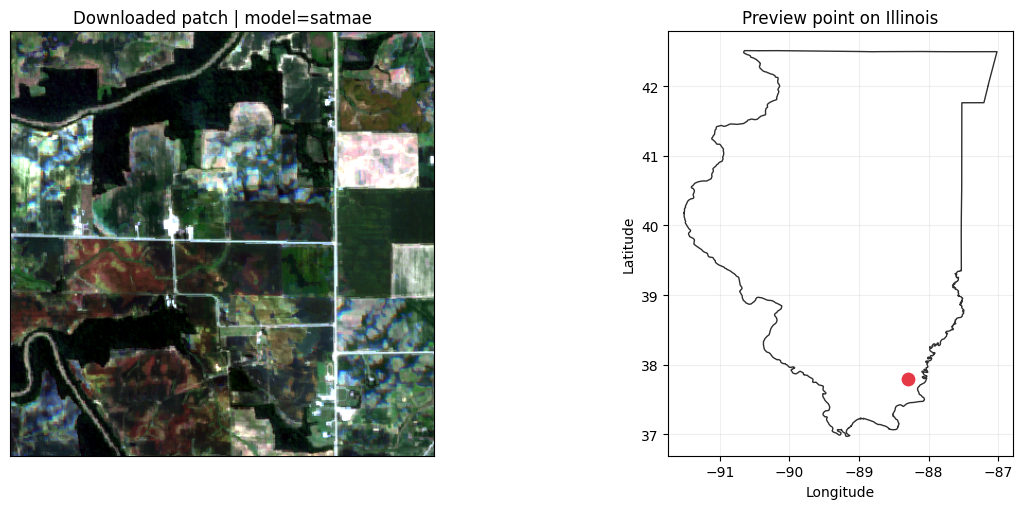

In [7]:
preview_dirs = resolve_preview_group_dirs([EXPORT_ROOT])
preview = load_one_preview_patch(preview_dirs, df) if preview_dirs else None

if preview is None:
    print("No preview patch found. Re-run export with SAVE_INPUTS=1 if you want this figure.")
else:
    chw = preview["chw"]
    if chw.shape[0] >= 3:
        rgb = np.transpose(chw[:3], (1, 2, 0))
    else:
        mono = chw[0]
        rgb = np.stack([mono, mono, mono], axis=-1)
    rgb_show = stretch_rgb(rgb)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), width_ratios=[1.0, 1.1])
    axes[0].imshow(rgb_show)
    axes[0].set_title(f"Downloaded patch | model={preview['model']}")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    draw_illinois_boundary(axes[1], color="#2f2f2f", linewidth=1.0)
    if np.isfinite(preview["lon"]) and np.isfinite(preview["lat"]):
        axes[1].scatter(
            [preview["lon"]],
            [preview["lat"]],
            s=120,
            color="#e63946",
            edgecolors="white",
            linewidths=1.0,
            zorder=3,
        )
    axes[1].set_title("Preview point on Illinois")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## 3. Load Exported Embeddings

We align each exported `.npz` back to the SPAM row by `(lon, lat)`.

In [8]:
point_to_row = {point_key(row.lon, row.lat): i for i, row in enumerate(df.itertuples(index=False))}
vectors_by_model = {}

for pm, npz_path, _ in iter_export_points(EXPORT_ROOT):
    row_index = point_row_index(pm, point_to_row)
    if row_index is None or not npz_path.exists():
        continue

    with np.load(npz_path, allow_pickle=False) as bundle:
        for model, vec in iter_model_vectors(bundle, pm):
            vectors_by_model.setdefault(model, {})[int(row_index)] = vec

X_by_model = {}
summary_rows = []

for model, row_map in sorted(vectors_by_model.items()):
    dims = {int(vec.shape[0]) for vec in row_map.values()}
    if len(dims) != 1:
        print(f"skip {model}: inconsistent dims {sorted(dims)}")
        continue

    dim = dims.pop()
    X = np.full((len(df), dim), np.nan, dtype=np.float32)
    for row_index, vec in row_map.items():
        X[row_index] = vec

    valid_rows = int(np.isfinite(X).all(axis=1).sum())
    X_by_model[model] = X
    summary_rows.append(
        {
            "model": model,
            "dim": dim,
            "valid_rows": valid_rows,
            "coverage": valid_rows / len(df),
        }
    )

embed_df = (
    pd.DataFrame(summary_rows).sort_values("coverage", ascending=False).reset_index(drop=True)
)
if embed_df.empty:
    raise RuntimeError(f"No usable embeddings found in {EXPORT_ROOT}.")

embed_df

,model,dim,valid_rows,coverage
0,agrifm,1024,991,1.0
1,dofa,768,991,1.0
2,remoteclip,768,991,1.0
3,satmae,1024,991,1.0
4,satmaepp,1024,991,1.0
5,terrafm,768,991,1.0
6,thor,768,991,1.0
7,wildsat,768,991,1.0


## 4. Train a Simple Regressor

We use one simple baseline only: `RandomForestRegressor`.

In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


y = df["label"].to_numpy(dtype=np.float32)
results = []
pred_by_model = {}

for model, X in X_by_model.items():
    valid_idx = np.where(np.isfinite(X).all(axis=1) & np.isfinite(y))[0]

    if len(valid_idx) < MIN_SAMPLES:
        results.append(
            {
                "model": model,
                "r2": np.nan,
                "rmse": np.nan,
                "mae": np.nan,
                "n_total": int(len(valid_idx)),
                "note": f"skip: need at least {MIN_SAMPLES} rows",
            }
        )
        continue

    idx_train, idx_test = train_test_split(valid_idx, test_size=TEST_SIZE, random_state=42)

    reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg.fit(X[idx_train], y[idx_train])
    pred = reg.predict(X[idx_test]).astype(np.float32)

    results.append(
        {
            "model": model,
            "r2": r2_score(y[idx_test], pred),
            "rmse": rmse(y[idx_test], pred),
            "mae": mean_absolute_error(y[idx_test], pred),
            "n_total": int(len(valid_idx)),
            "n_test": int(len(idx_test)),
            "note": "ok",
        }
    )
    pred_by_model[model] = {"idx_test": idx_test, "y_true": y[idx_test], "y_pred": pred}

result_df = (
    pd.DataFrame(results)
    .sort_values("r2", ascending=False, na_position="last")
    .reset_index(drop=True)
)
result_df

,model,r2,rmse,mae,n_total,n_test,note
0,agrifm,0.308466,0.473007,0.300528,991,248,ok
1,thor,0.289944,0.479300,0.296454,991,248,ok
2,terrafm,0.256629,0.490415,0.309522,991,248,ok
3,satmaepp,0.182635,0.514243,0.323742,991,248,ok
4,remoteclip,0.105403,0.537991,0.345528,991,248,ok
5,wildsat,0.087153,0.543450,0.343502,991,248,ok
6,satmae,0.021701,0.562596,0.354478,991,248,ok
7,dofa,0.018950,0.563387,0.358460,991,248,ok


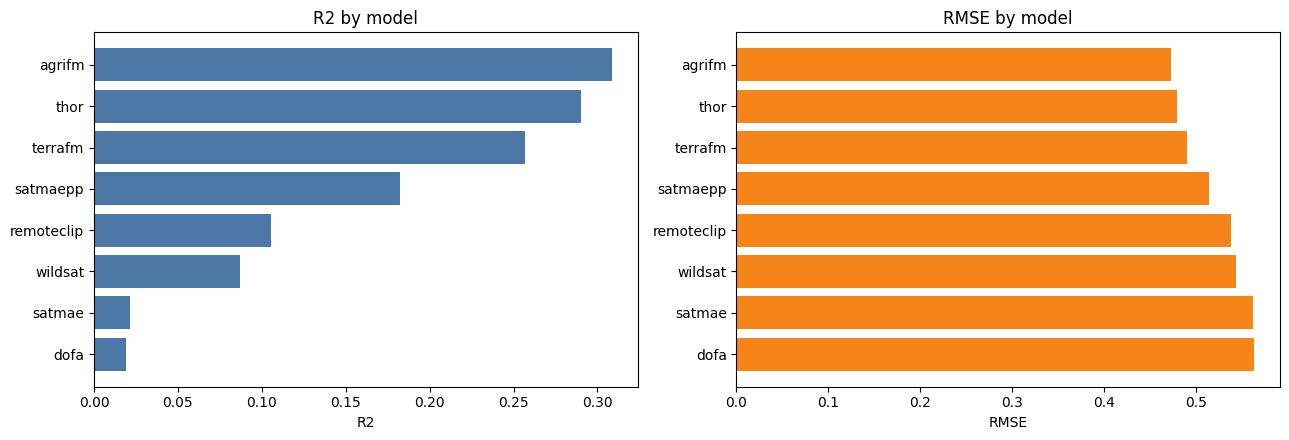

In [10]:
valid_result_df = result_df.dropna(subset=["r2"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

if not valid_result_df.empty:
    plot_df = valid_result_df.sort_values("r2", ascending=True)
    axes[0].barh(plot_df["model"], plot_df["r2"], color="#4c78a8")
axes[0].set_title("R2 by model")
axes[0].set_xlabel("R2")

if not valid_result_df.empty:
    plot_df = valid_result_df.sort_values("rmse", ascending=False)
    axes[1].barh(plot_df["model"], plot_df["rmse"], color="#f58518")
axes[1].set_title("RMSE by model")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

## 5. Inspect the Best Model

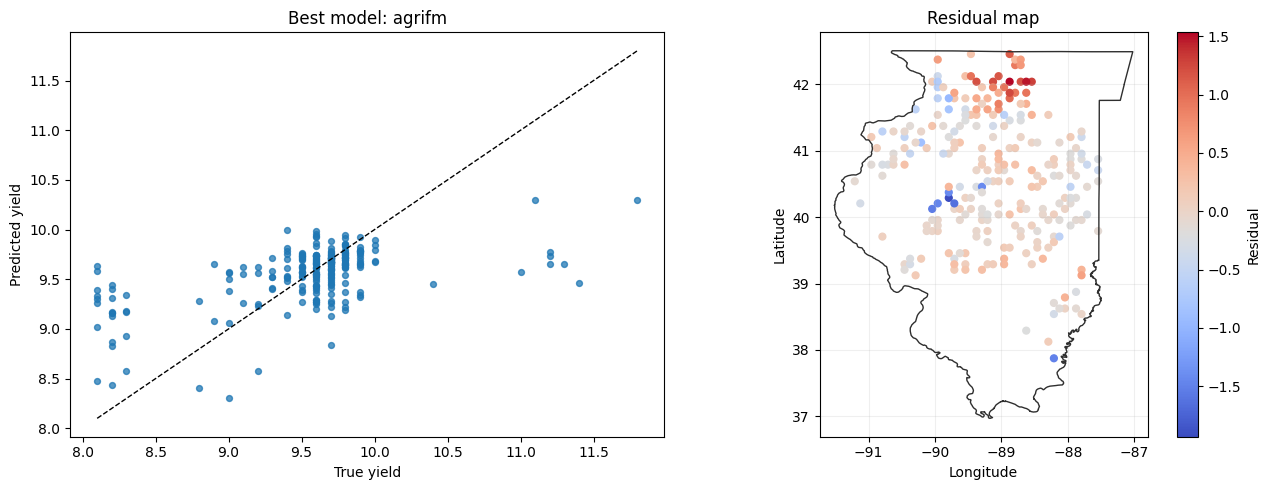

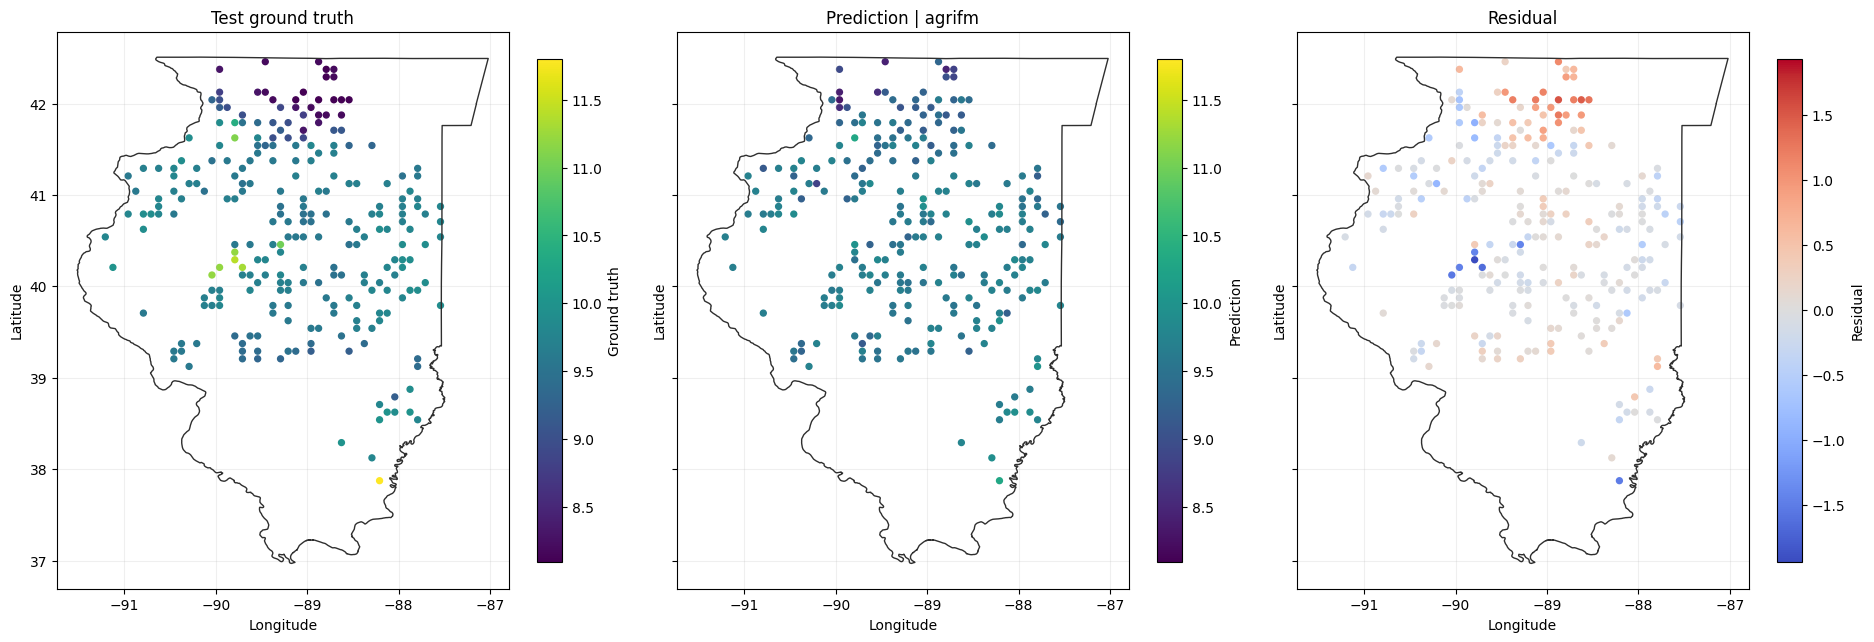

best_model=agrifm


In [12]:
valid_result_df = result_df.dropna(subset=["r2"]).copy()
if valid_result_df.empty:
    print("No valid model to plot.")
else:
    best_model = valid_result_df.iloc[0]["model"]
    best_pred = pred_by_model[best_model]

    test_df = df.iloc[best_pred["idx_test"]].copy()
    test_df["pred"] = best_pred["y_pred"]
    test_df["resid"] = test_df["pred"] - test_df["label"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    lo = float(min(test_df["label"].min(), test_df["pred"].min()))
    hi = float(max(test_df["label"].max(), test_df["pred"].max()))
    axes[0].scatter(test_df["label"], test_df["pred"], s=18, alpha=0.75)
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
    axes[0].set_title(f"Best model: {best_model}")
    axes[0].set_xlabel("True yield")
    axes[0].set_ylabel("Predicted yield")

    draw_illinois_boundary(axes[1], color="#2f2f2f", linewidth=1.0)
    sc = axes[1].scatter(test_df["lon"], test_df["lat"], c=test_df["resid"], s=24, cmap="coolwarm")
    plt.colorbar(sc, ax=axes[1], label="Residual")
    axes[1].set_title("Residual map")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    value_min = float(min(test_df["label"].min(), test_df["pred"].min()))
    value_max = float(max(test_df["label"].max(), test_df["pred"].max()))
    resid_max = float(np.nanmax(np.abs(test_df["resid"].to_numpy())))
    resid_max = max(resid_max, 1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), sharex=True, sharey=True)
    ax_gt, ax_pred, ax_res = axes

    for ax in axes:
        draw_illinois_boundary(ax, color="#2f2f2f", linewidth=1.0)

    sc_gt = ax_gt.scatter(
        test_df["lon"],
        test_df["lat"],
        c=test_df["label"],
        s=18,
        cmap="viridis",
        vmin=value_min,
        vmax=value_max,
    )
    fig.colorbar(sc_gt, ax=ax_gt, shrink=0.82, label="Ground truth")
    ax_gt.set_title("Test ground truth")

    sc_pred = ax_pred.scatter(
        test_df["lon"],
        test_df["lat"],
        c=test_df["pred"],
        s=18,
        cmap="viridis",
        vmin=value_min,
        vmax=value_max,
    )
    fig.colorbar(sc_pred, ax=ax_pred, shrink=0.82, label="Prediction")
    ax_pred.set_title(f"Prediction | {best_model}")

    sc_res = ax_res.scatter(
        test_df["lon"],
        test_df["lat"],
        c=test_df["resid"],
        s=18,
        cmap="coolwarm",
        vmin=-resid_max,
        vmax=resid_max,
    )
    fig.colorbar(sc_res, ax=ax_res, shrink=0.82, label="Residual")
    ax_res.set_title("Residual")

    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(f"best_model={best_model}")
    test_df.head()